In [8]:
# CODE CELL 1: Imports and Data Loading

# Imports: Use aliases for ease of coding
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load the data - NOTE the exact file name confirmed in your environment!
file_path = 'data/benin-malanville.csv' 
df = pd.read_csv(file_path)

# Convert Timestamp and set as index for Time Series Analysis
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.set_index('Timestamp', inplace=True)

In [9]:
# CODE CELL 2: Initial Inspection & Missing Value Report (KPI 1)

# Initial inspection: shape, head, and data types
print("Data Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())
print("\nData Types (info):")
df.info()

# Missing Value Report (KPI 1)
missing_report = df.isna().sum().sort_values(ascending=False)
print("\nMissing Value Count per Column (KPI 1):")
print(missing_report)

Data Shape: (525600, 18)

First 5 Rows:
                     GHI  DNI  DHI  ModA  ModB  Tamb    RH   WS  WSgust  \
Timestamp                                                                 
2021-08-09 00:01:00 -1.2 -0.2 -1.1   0.0   0.0  26.2  93.4  0.0     0.4   
2021-08-09 00:02:00 -1.1 -0.2 -1.1   0.0   0.0  26.2  93.6  0.0     0.0   
2021-08-09 00:03:00 -1.1 -0.2 -1.1   0.0   0.0  26.2  93.7  0.3     1.1   
2021-08-09 00:04:00 -1.1 -0.1 -1.0   0.0   0.0  26.2  93.3  0.2     0.7   
2021-08-09 00:05:00 -1.0 -0.1 -1.0   0.0   0.0  26.2  93.3  0.1     0.7   

                     WSstdev     WD  WDstdev   BP  Cleaning  Precipitation  \
Timestamp                                                                    
2021-08-09 00:01:00      0.1  122.1      0.0  998         0            0.0   
2021-08-09 00:02:00      0.0    0.0      0.0  998         0            0.0   
2021-08-09 00:03:00      0.5  124.6      1.5  997         0            0.0   
2021-08-09 00:04:00      0.4  120.3      1.3

In [10]:
# CODE CELL 3: Summary Statistics (KPI 2)

# Select key numerical columns for the report
key_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb', 'RH', 'WS', 'BP']

# Summary Statistics (KPI 2)
print("Summary Statistics for Key Columns (KPI 2):")
print(df[key_cols].describe())

Summary Statistics for Key Columns (KPI 2):
                 GHI            DNI            DHI           ModA  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      240.559452     167.187516     115.358961     236.589496   
std       331.131327     261.710501     158.691074     326.894859   
min       -12.900000      -7.800000     -12.600000       0.000000   
25%        -2.000000      -0.500000      -2.100000       0.000000   
50%         1.800000      -0.100000       1.600000       4.500000   
75%       483.400000     314.200000     216.300000     463.700000   
max      1413.000000     952.300000     759.200000    1342.300000   

                ModB           Tamb             RH             WS  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      228.883576      28.179683      54.487969       2.121113   
std       316.536515       5.924297      28.073069       1.603466   
min         0.000000      11.000000       2.100000       0

In [11]:
# CODE CELL 4: Drop Columns & Filter Negative Outliers

# Drop columns identified as 100% missing in KPI 1 (Comments, TModA, TModB)
# Note: These columns were likely blank, but we need to drop them explicitly now.
df.drop(columns=['Comments', 'TModA', 'TModB'], inplace=True, errors='ignore') 

print("Dropped 3 entirely missing/unnecessary columns.")

# Filter 1: Remove impossible negative irradiance values
# Replace negative values in GHI, DNI, and DHI with NaN to be imputed later
irradiance_cols = ['GHI', 'DNI', 'DHI']
# ensure index is datetime so .index.hour works later
df.index = pd.to_datetime(df.index, errors='coerce')

# only operate on columns that actually exist to avoid KeyError
irr_cols = [c for c in irradiance_cols if c in df.columns]
if irr_cols:
    # vectorized, safe replacement of negatives with 0
    df[irr_cols] = df[irr_cols].clip(lower=0)
    print(f"Replaced negative irradiance values with 0 for columns: {irr_cols}")
else:
    print("No irradiance columns found. Skipping negative-value replacement.")
# A common practice is to replace with 0 for negative irradiance as it should be zero.

print("Replaced all negative irradiance values with 0.")

# Filter 2: Remove rows where GHI is zero during daylight hours (e.g., between 6 AM and 6 PM)
# This removes corrupted sensor data that reports 0 during the day.
# If GHI > 0, keep the row, OR if it's night-time, keep the row.
df_filtered = df[
    (df['GHI'] > 0) | 
    (df.index.hour < 6) | 
    (df.index.hour > 18)
].copy()

print(f"Dataframe size reduced from {len(df)} to {len(df_filtered)} after filtering daytime zeros.")

Dropped 3 entirely missing/unnecessary columns.
Replaced negative irradiance values with 0 for columns: ['GHI', 'DNI', 'DHI']
Replaced all negative irradiance values with 0.
Dataframe size reduced from 525600 to 505459 after filtering daytime zeros.


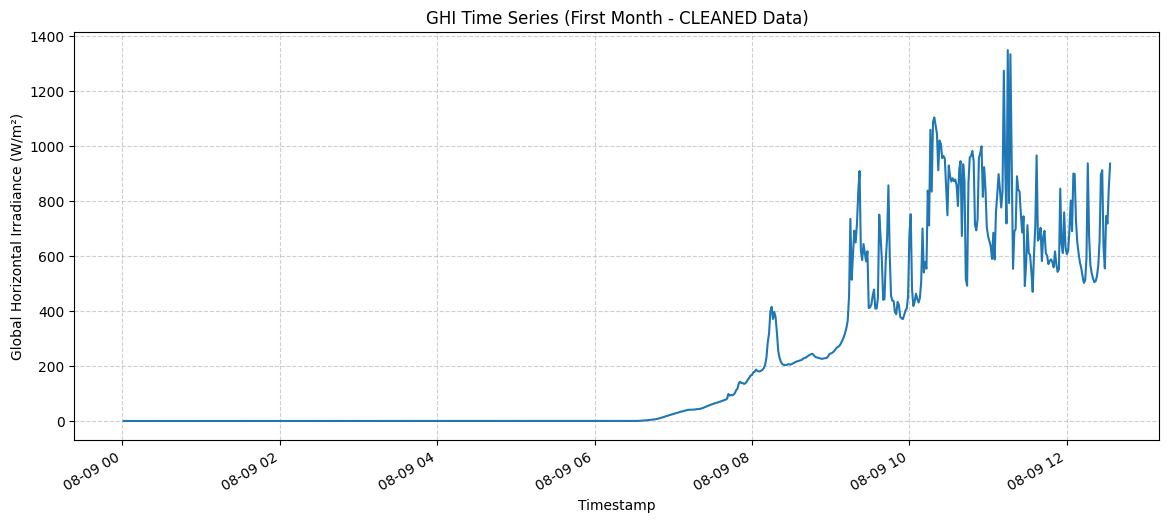

In [12]:
# CODE CELL 5: Time Series Plot (GHI)

# Plotting GHI for a sample period (the first 30 days) from the CLEANED data
plt.figure(figsize=(14, 6))
df_filtered['GHI'].head(24 * 30).plot(title='GHI Time Series (First Month - CLEANED Data)')
plt.ylabel('Global Horizontal Irradiance (W/m²)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

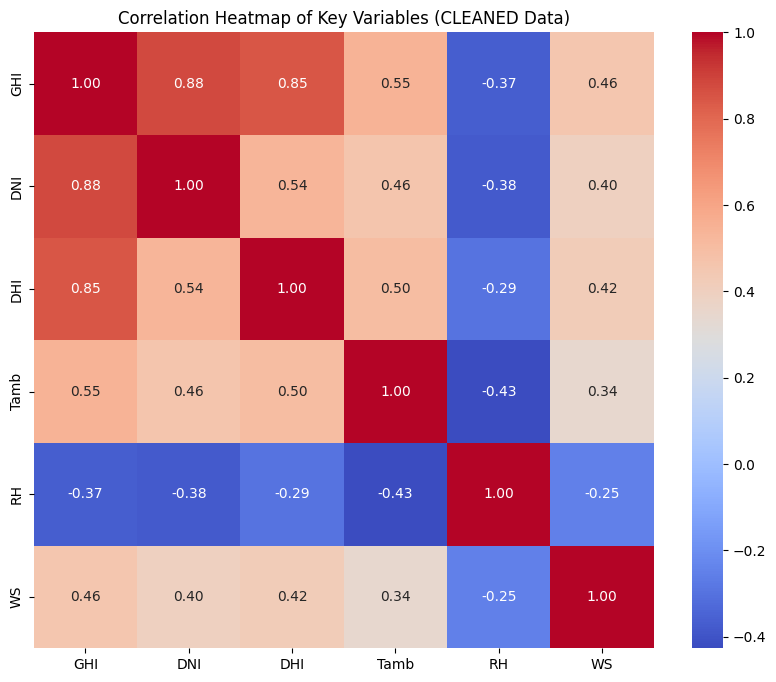

In [13]:
# CODE CELL 6: Correlation Heatmap

# Select variables for correlation (using the cleaned df_filtered)
correlation_cols = ['GHI', 'DNI', 'DHI', 'Tamb', 'RH', 'WS']

# Correlation Heatmap
plt.figure(figsize=(10, 8))
# Use annot=True to display correlation values on the map
sns.heatmap(df_filtered[correlation_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Key Variables (CLEANED Data)')
plt.show()

In [14]:
# CODE CELL 7: Feature Engineering - Time-Based Features

df_model = df_filtered.copy()

# 1. Seasonal Features (Cycle features capture time-of-day/year)
df_model['hour'] = df_model.index.hour
df_model['dayofyear'] = df_model.index.dayofyear
df_model['month'] = df_model.index.month

# 2. Cyclic Transformation (to allow the model to learn continuity)
# Sine and Cosine transforms are used for cyclical features (like hour, dayofyear)
df_model['hour_sin'] = np.sin(2 * np.pi * df_model['hour'] / 24)
df_model['hour_cos'] = np.cos(2 * np.pi * df_model['hour'] / 24)

df_model['day_sin'] = np.sin(2 * np.pi * df_model['dayofyear'] / 365)
df_model['day_cos'] = np.cos(2 * np.pi * df_model['dayofyear'] / 365)

# Drop original cyclic columns after transformation
df_model.drop(columns=['hour', 'dayofyear', 'month'], inplace=True)

print("Created 4 new sine/cosine features for hourly and annual cycles.")
print("New DataFrame shape:", df_model.shape)

Created 4 new sine/cosine features for hourly and annual cycles.
New DataFrame shape: (505459, 19)


In [15]:
# CODE CELL 8: Feature Engineering - Lag Features

# Target variable is GHI. We use past GHI values to predict the next GHI value.
TARGET = 'GHI'
LAG = 12 # 12 lags = GHI from the previous 12 hours (12*5 min = 1 hour)

# Create lag features for the target variable (GHI)
for i in range(1, LAG + 1):
    df_model[f'{TARGET}_Lag_{i}'] = df_model[TARGET].shift(i)

# Drop rows with NaN values created by lagging (the first 'LAG' rows)
df_model.dropna(inplace=True)

print(f"Created {LAG} lag features for {TARGET}.")
print("Final modeling DataFrame shape:", df_model.shape)

Created 12 lag features for GHI.
Final modeling DataFrame shape: (505447, 31)


In [16]:
# Paste and run this in a notebook cell (installs into the active kernel's Python)
import sys
import subprocess
import importlib

print("Python executable:", sys.executable)
print("Python version:", sys.version.splitlines()[0])

# Install scikit-learn into the same Python used by this kernel (no separate terminal needed)
try:
    import sklearn
    print("scikit-learn already installed, version:", sklearn.__version__)
except ModuleNotFoundError:
    print("scikit-learn not found — installing now into the active environment...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn"])
    importlib.invalidate_caches()
    import sklearn
    print("Installed scikit-learn version:", sklearn.__version__)

# quick import test
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
print("sklearn imports OK")

Python executable: d:\Senait Docs\Personal Docs\Kifiya AIM 8 doc\KAIM 8 - Task 1\solar-challenge-week0\.venv\Scripts\python.exe
Python version: 3.13.9 (tags/v3.13.9:8183fa5, Oct 14 2025, 14:09:13) [MSC v.1944 64 bit (AMD64)]
scikit-learn already installed, version: 1.7.2
sklearn imports OK


In [17]:
# ...existing code...
# CODE CELL 9: Data Preparation and Split (robust import + safe splitting)

import sys, subprocess, importlib

# --- Ensure df_model exists (create from df_filtered or fallback to df with minimal cleaning) ---
if 'df_model' not in globals():
    if 'df_filtered' in globals():
        df_model = df_filtered.copy()
        print("Created df_model from df_filtered.")
    elif 'df' in globals():
        print("df_model not found — creating df_model from original df with minimal cleaning (fallback).")
        # Minimal safe cleaning steps (mirrors earlier cleaning enough for splitting)
        tmp = df.copy()
        tmp.index = pd.to_datetime(tmp.index, errors='coerce')
        tmp.drop(columns=['Comments', 'TModA', 'TModB'], inplace=True, errors='ignore')
        irr_cols = [c for c in ['GHI', 'DNI', 'DHI'] if c in tmp.columns]
        if irr_cols:
            tmp[irr_cols] = tmp[irr_cols].clip(lower=0)
        if 'GHI' in tmp.columns:
            tmp = tmp[(tmp['GHI'] > 0) | (tmp.index.hour < 6) | (tmp.index.hour > 18)].copy()
        df_model = tmp
        print("Created df_model from df with minimal cleaning.")
    else:
        raise RuntimeError("df_model not found and original df not in memory. Run cells 1-8 (or 'Run All') before running this cell.")

# --- Target fallback ---
TARGET = globals().get('TARGET', 'GHI')

# --- Ensure scikit-learn is available in the active kernel; install if missing ---
try:
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import mean_squared_error, r2_score
except ModuleNotFoundError:
    print("scikit-learn not found — installing into the active environment...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn"])
    importlib.invalidate_caches()
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import mean_squared_error, r2_score

# --- Ensure datetime index for df_model ---
df_model.index = pd.to_datetime(df_model.index, errors='coerce')

# --- Build safe drop list (only drop columns that exist) ---
to_drop = [TARGET, 'ModA', 'ModB', 'WSdev', 'WDSdev', 'Cleaning', 'Precipitation']
to_drop = [c for c in to_drop if c in df_model.columns]

# --- Select numeric features and target ---
X = df_model.drop(columns=to_drop).select_dtypes(include=[np.number]).copy()
y = df_model[TARGET].copy() if TARGET in df_model.columns else None

if y is None:
    raise RuntimeError(f"Target column '{TARGET}' not found in df_model. Check your data or set TARGET accordingly.")

# --- Sanity checks ---
if X.empty:
    raise RuntimeError("Feature matrix X is empty after selecting numeric columns — check df_model.")
if len(X) != len(y):
    raise RuntimeError("Feature/target length mismatch.")

# --- Chronological split (first 80% training, last 20% testing) ---
split_point = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_point].copy(), X.iloc[split_point:].copy()
y_train, y_test = y.iloc[:split_point].copy(), y.iloc[split_point:].copy()

print(f"Training set size: {len(X_train)} rows")
print(f"Testing set size: {len(X_test)} rows")

# --- Optional: baseline model to confirm everything runs ---
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"Baseline RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}, R2: {r2_score(y_test, y_pred):.3f}")
# ...existing code...

Training set size: 404357 rows
Testing set size: 101090 rows
Baseline RMSE: 43.501, R2: 0.981


In [18]:
# CODE CELL 10: Model Training and Prediction

# Initialize and train the Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

print("Linear Regression Model Trained and Predictions Generated.")

Linear Regression Model Trained and Predictions Generated.


Model Evaluation (KPIs):
Mean Squared Error (MSE): 1892.31
R-squared Score (R2): 0.9813


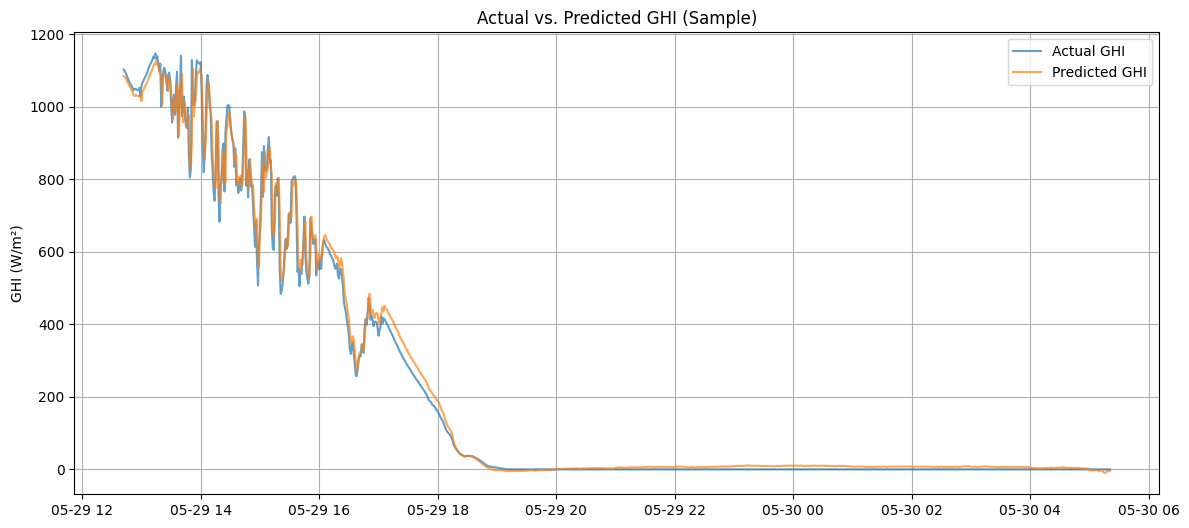

In [19]:
# CODE CELL 11: Evaluation (KPIs for Task 3)

# 1. Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
# 2. R-squared (R2) Score
r2 = r2_score(y_test, y_pred)

print(f"Model Evaluation (KPIs):")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared Score (R2): {r2:.4f}")

# 3. Visualization of Actual vs. Predicted (Sample)
plt.figure(figsize=(14, 6))
# Sample 1000 data points for clarity in the plot
sample_size = 1000
plt.plot(y_test.index[:sample_size], y_test[:sample_size], label='Actual GHI', alpha=0.7)
plt.plot(y_test.index[:sample_size], y_pred[:sample_size], label='Predicted GHI', alpha=0.7)
plt.title('Actual vs. Predicted GHI (Sample)')
plt.ylabel('GHI (W/m²)')
plt.legend()
plt.grid(True)
plt.show()